# 03 — Static and Rainfall Feature Construction

## Objective
Construct the core features required for the flood-risk proxy:

- Static features:
  - elevation
  - slope

- Dynamic features:
  - daily rainfall

## Outputs
- Grid-level elevation and slope
- Grid-level rainfall time series
- Saved intermediate parquet files

## Notes
This notebook builds the inputs for the proxy flood-risk label defined in Notebook 02.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import *

import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt

print_config_summary()

Project: flood-prediction
City: Houston
BBOX: {'lon_min': -95.8, 'lat_min': 29.4, 'lon_max': -95.0, 'lat_max': 30.2}
CRS_GEO: EPSG:4326
CRS_PROJECTED: EPSG:3857
Grid size (m): 5000
Grid file: /Users/suvo/Projects/flood-prediction/data/interim/grids/houston_grid_1km.parquet


In [3]:
grid_gdf = gpd.read_parquet(GRID_FILE)

print("Grid shape:", grid_gdf.shape)
grid_gdf.head()

Grid shape: (378, 2)


,grid_id,geometry
0,0,"POLYGON ((-95.75508 29.43912, -95.75508 29.4, ..."
1,1,"POLYGON ((-95.75508 29.47823, -95.75508 29.439..."
2,2,"POLYGON ((-95.75508 29.51733, -95.75508 29.478..."
3,3,"POLYGON ((-95.75508 29.5564, -95.75508 29.5173..."
4,4,"POLYGON ((-95.75508 29.59547, -95.75508 29.556..."


In [4]:
import glob

dem_files = sorted(ELEVATION_RAW_DIR.glob("USGS_13_*.tif"))

print("DEM files:")
for f in dem_files:
    print(f)

srcs = [rasterio.open(f) for f in dem_files]

DEM files:
/Users/suvo/Projects/flood-prediction/data/raw/elevation/USGS_13_n29w096.tif
/Users/suvo/Projects/flood-prediction/data/raw/elevation/USGS_13_n30w096.tif


In [5]:
mosaic, transform = merge(srcs)

print("Mosaic shape:", mosaic.shape)

Mosaic shape: (1, 21612, 10812)


In [6]:
from rasterio.io import MemoryFile

memfile = MemoryFile()
with memfile.open(
    driver="GTiff",
    height=mosaic.shape[1],
    width=mosaic.shape[2],
    count=1,
    dtype=mosaic.dtype,
    crs=srcs[0].crs,
    transform=transform,
) as dataset:
    dataset.write(mosaic)

    dem_dataset = dataset

In [7]:
import rasterio
from rasterio.merge import merge

srcs = [rasterio.open(f) for f in dem_files]
mosaic, transform = merge(srcs)

dem_meta = srcs[0].meta.copy()
dem_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

In [8]:
grid_proj = grid_gdf.to_crs(dem_meta["crs"])

In [9]:
from rasterio.features import geometry_mask

elev_values = []

for geom in grid_proj.geometry:
    mask_arr = geometry_mask(
        [geom],
        transform=transform,
        invert=True,
        out_shape=(mosaic.shape[1], mosaic.shape[2])
    )
    
    values = mosaic[0][mask_arr]
    
    # Remove nodata
    values = values[values > -1e5]
    
    if len(values) == 0:
        elev_values.append(np.nan)
    else:
        elev_values.append(values.mean())

grid_proj["elevation"] = elev_values

In [10]:
grid_gdf["elevation"] = grid_proj["elevation"].values

In [11]:
print(grid_gdf["elevation"].describe())

count    288.000000
mean      19.314452
std       10.779189
min        2.196847
25%       11.587469
50%       17.808608
75%       25.159256
max       57.432652
Name: elevation, dtype: float64


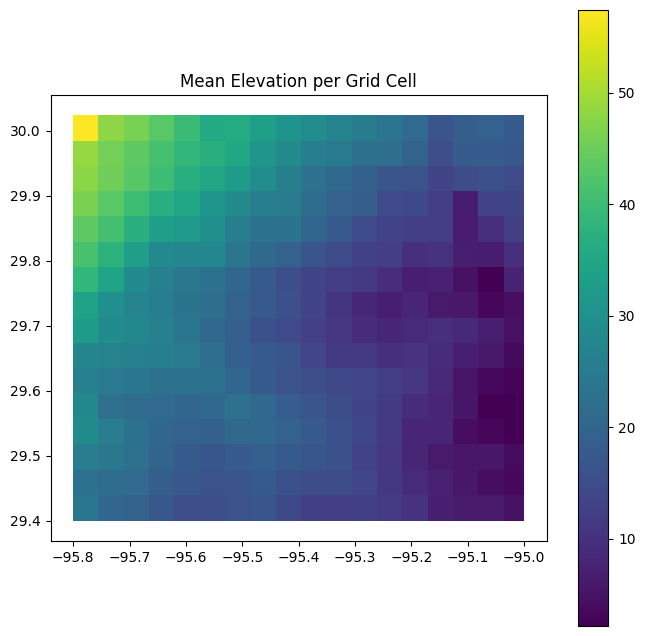

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

grid_gdf.plot(
    column="elevation",
    ax=ax,
    legend=True
)

ax.set_title("Mean Elevation per Grid Cell")
plt.show()

In [19]:
from scipy.ndimage import gaussian_filter

dem_smooth = gaussian_filter(dem_array, sigma=5)

In [20]:
from scipy.ndimage import sobel

dx = sobel(dem_smooth, axis=1)
dy = sobel(dem_smooth, axis=0)

slope = np.sqrt(dx**2 + dy**2)

In [21]:
slope_values = []

for geom in grid_proj.geometry:
    mask_arr = geometry_mask(
        [geom],
        transform=transform,
        invert=True,
        out_shape=(slope.shape[0], slope.shape[1])
    )
    
    values = slope[mask_arr]
    
    if len(values) == 0:
        slope_values.append(np.nan)
    else:
        slope_values.append(values.mean())

grid_proj["slope"] = slope_values

In [22]:
grid_gdf["slope"] = grid_proj["slope"].values

In [23]:
print(grid_gdf["slope"].describe())

count    288.000000
mean       0.387377
std        0.200982
min        0.081756
25%        0.265116
50%        0.343460
75%        0.455925
max        1.767008
Name: slope, dtype: float64


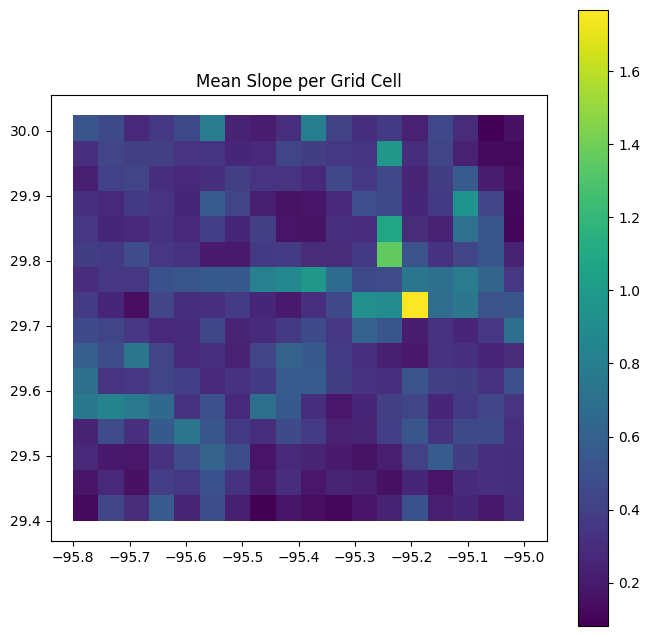

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

grid_gdf.plot(
    column="slope",
    ax=ax,
    legend=True
)

ax.set_title("Mean Slope per Grid Cell")
plt.show()

In [29]:
rain_files = sorted(RAINFALL_RAW_DIR.glob("rain_*.csv"))

print("Rainfall files found:", len(rain_files))
for f in rain_files:
    print(f.name)

Rainfall files found: 9
rain_h01.csv
rain_h02.csv
rain_h03.csv
rain_h04.csv
rain_h05.csv
rain_h06.csv
rain_h07.csv
rain_h08.csv
rain_h09.csv


In [32]:
rain_dfs = []

for f in rain_files:
    # metadata values are on line 1
    meta_values = pd.read_csv(f, skiprows=1, nrows=1, header=None)
    
    lat = float(meta_values.iloc[0, 0])
    lon = float(meta_values.iloc[0, 1])
    point_elev = float(meta_values.iloc[0, 2])

    # actual rainfall table starts at line 3
    df = pd.read_csv(f, skiprows=3)

    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={"precipitation_sum (mm)": "precipitation_mm"})
    df = df[["time", "precipitation_mm"]].copy()

    df["latitude"] = lat
    df["longitude"] = lon
    df["point_elevation"] = point_elev
    df["source_file"] = f.name

    rain_dfs.append(df)

rain = pd.concat(rain_dfs, ignore_index=True)

rain["time"] = pd.to_datetime(rain["time"], errors="coerce")
rain["precipitation_mm"] = pd.to_numeric(rain["precipitation_mm"], errors="coerce")

rain = rain.dropna(subset=["time", "precipitation_mm"]).copy()

print("Final rainfall shape:", rain.shape)
rain.head()

Final rainfall shape: (29583, 6)


,time,precipitation_mm,latitude,longitude,point_elevation,source_file
0,2017-01-01,0.6,29.490334,-95.722534,23.0,rain_h01.csv
1,2017-01-02,3.6,29.490334,-95.722534,23.0,rain_h01.csv
2,2017-01-03,0.0,29.490334,-95.722534,23.0,rain_h01.csv
3,2017-01-04,0.0,29.490334,-95.722534,23.0,rain_h01.csv
4,2017-01-05,1.2,29.490334,-95.722534,23.0,rain_h01.csv


In [33]:
print(rain["precipitation_mm"].describe())
print(rain[["latitude", "longitude"]].drop_duplicates().shape)

count    29583.000000
mean         5.016310
std         11.850661
min          0.000000
25%          0.000000
50%          0.600000
75%          4.100000
max        272.200000
Name: precipitation_mm, dtype: float64
(9, 2)


In [34]:
rain_points = rain[["latitude", "longitude", "source_file"]].drop_duplicates().copy()

rain_points_gdf = gpd.GeoDataFrame(
    rain_points,
    geometry=gpd.points_from_xy(rain_points["longitude"], rain_points["latitude"]),
    crs=CRS_GEO,
)

print(rain_points_gdf.shape)
rain_points_gdf

(9, 4)


,latitude,longitude,source_file,geometry
0,29.490334,-95.722534,rain_h01.csv,POINT (-95.72253 29.49033)
3287,29.490334,-95.410400,rain_h02.csv,POINT (-95.4104 29.49033)
6574,29.490334,-95.098270,rain_h03.csv,POINT (-95.09827 29.49033)
9861,29.771528,-95.749115,rain_h04.csv,POINT (-95.74912 29.77153)
13148,29.771528,-95.435550,rain_h05.csv,POINT (-95.43555 29.77153)
16435,29.771528,-95.121950,rain_h06.csv,POINT (-95.12195 29.77153)
19722,30.123022,-95.677580,rain_h07.csv,POINT (-95.67758 30.12302)
23009,30.123022,-95.362150,rain_h08.csv,POINT (-95.36215 30.12302)
26296,30.123022,-95.151855,rain_h09.csv,POINT (-95.15186 30.12302)


In [36]:
# Project to metric CRS first
grid_centroids_proj = grid_gdf.to_crs(CRS_PROJECTED)

# Compute centroids in projected space
grid_centroids_proj["geometry"] = grid_centroids_proj.geometry.centroid

# Convert back to geographic CRS
grid_centroids = grid_centroids_proj.to_crs(CRS_GEO)

In [38]:
grid_centroids_proj = grid_centroids.to_crs(CRS_PROJECTED)
rain_points_proj = rain_points_gdf.to_crs(CRS_PROJECTED)

grid_to_rain = gpd.sjoin_nearest(
    grid_centroids_proj[["grid_id", "geometry"]],
    rain_points_proj[["source_file", "geometry"]],
    how="left",
    distance_col="distance_m"
)

In [39]:
print(grid_to_rain.shape)
grid_to_rain.head()

(378, 5)


,grid_id,geometry,index_right,source_file,distance_m
0,0,POINT (-10661907.218 3429156.25),0,rain_h01.csv,10924.998932
1,1,POINT (-10661907.218 3434156.25),0,rain_h01.csv,7340.288339
2,2,POINT (-10661907.218 3439156.25),0,rain_h01.csv,6197.101269
3,3,POINT (-10661907.218 3444156.25),0,rain_h01.csv,8539.806518
4,4,POINT (-10661907.218 3449156.25),0,rain_h01.csv,12548.008870


In [40]:
print(grid_to_rain["distance_m"].describe())

count      378.000000
mean     13159.437493
std       5498.590251
min        410.682638
25%       9383.623159
50%      12884.037966
75%      16936.488287
max      26158.025395
Name: distance_m, dtype: float64


In [41]:
grid_rain_map = grid_to_rain[["grid_id", "source_file"]].copy()
grid_rain_map.head()

,grid_id,source_file
0,0,rain_h01.csv
1,1,rain_h01.csv
2,2,rain_h01.csv
3,3,rain_h01.csv
4,4,rain_h01.csv


In [42]:
rainfall_grid = rain.merge(
    grid_rain_map,
    on="source_file",
    how="inner"
)

rainfall_grid = rainfall_grid[[
    "grid_id",
    "time",
    "precipitation_mm",
    "source_file"
]].copy()

print(rainfall_grid.shape)
rainfall_grid.head()

(1242486, 4)


,grid_id,time,precipitation_mm,source_file
0,0,2017-01-01,0.6,rain_h01.csv
1,1,2017-01-01,0.6,rain_h01.csv
2,2,2017-01-01,0.6,rain_h01.csv
3,3,2017-01-01,0.6,rain_h01.csv
4,4,2017-01-01,0.6,rain_h01.csv


In [43]:
rainfall_grid.groupby("grid_id")["time"].nunique().describe()

count     378.0
mean     3287.0
std         0.0
min      3287.0
25%      3287.0
50%      3287.0
75%      3287.0
max      3287.0
Name: time, dtype: float64

In [44]:
rainfall_grid = rainfall_grid.sort_values(["grid_id", "time"]).copy()

rainfall_grid["rain_3d"] = (
    rainfall_grid.groupby("grid_id")["precipitation_mm"]
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

rainfall_grid["rain_7d"] = (
    rainfall_grid.groupby("grid_id")["precipitation_mm"]
    .rolling(window=7, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

In [45]:
rainfall_grid[["precipitation_mm", "rain_3d", "rain_7d"]].describe()

,precipitation_mm,rain_3d,rain_7d
count,1.242486e+06,1.242486e+06,1.242486e+06
mean,5.042507e+00,1.512752e+01,3.529489e+01
std,1.189608e+01,2.559503e+01,4.357007e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.000000e+00,8.300000e+00
50%,6.000000e-01,5.700000e+00,2.200000e+01
75%,4.100000e+00,1.910000e+01,4.600000e+01
max,2.722000e+02,4.993000e+02,6.979000e+02


In [46]:
grid_gdf.to_parquet(PROCESSED_DIR / "grid_static_features.parquet", index=False)

In [47]:
rainfall_grid.to_parquet(PROCESSED_DIR / "grid_rainfall_timeseries.parquet", index=False)

## Susceptibility Score

In [48]:
grid_static = grid_gdf[["grid_id", "elevation", "slope", "geometry"]].copy()

elev_min = grid_static["elevation"].min()
elev_max = grid_static["elevation"].max()

grid_static["elevation_norm"] = (
    (grid_static["elevation"] - elev_min) / (elev_max - elev_min)
)

# Lower elevation = higher susceptibility
grid_static["low_elevation_score"] = 1 - grid_static["elevation_norm"]

grid_static[["grid_id", "elevation", "low_elevation_score"]].head()

,grid_id,elevation,low_elevation_score
0,0,23.960281,0.605990
1,1,22.753338,0.627841
2,2,25.431944,0.579347
3,3,28.746405,0.519342
4,4,27.924585,0.534220


In [49]:
sus_threshold = grid_static["low_elevation_score"].quantile(0.75)

grid_static["is_susceptible"] = (
    grid_static["low_elevation_score"] >= sus_threshold
).astype(int)

print("Susceptibility threshold:", sus_threshold)
print(grid_static["is_susceptible"].value_counts(normalize=True))

Susceptibility threshold: 0.8299903040782985
is_susceptible
0    0.809524
1    0.190476
Name: proportion, dtype: float64


In [50]:
rain_threshold = rainfall_grid["rain_3d"].quantile(0.90)

print("Rainfall threshold (90th percentile of rain_3d):", rain_threshold)

Rainfall threshold (90th percentile of rain_3d): 40.79999999999998


In [51]:
rainfall_grid["is_high_rain"] = (
    rainfall_grid["rain_3d"] >= rain_threshold
).astype(int)

rainfall_grid["is_high_rain"].value_counts(normalize=True)

is_high_rain
0    0.899988
1    0.100012
Name: proportion, dtype: float64

In [52]:
model_df = rainfall_grid.merge(
    grid_static[["grid_id", "low_elevation_score", "is_susceptible"]],
    on="grid_id",
    how="left"
)

model_df.shape

(1242486, 9)

In [53]:
model_df["proxy_label"] = (
    (model_df["is_susceptible"] == 1) &
    (model_df["is_high_rain"] == 1)
).astype(int)

model_df["proxy_label"].value_counts(normalize=True)

proxy_label
0    0.978335
1    0.021665
Name: proportion, dtype: float64

In [54]:
print("Proxy label mean:", model_df["proxy_label"].mean())

Proxy label mean: 0.021664630426419293


In [55]:
print("Susceptible cell fraction:", grid_static["is_susceptible"].mean())
print("High rain fraction:", rainfall_grid["is_high_rain"].mean())
print("Proxy label fraction:", model_df["proxy_label"].mean())

Susceptible cell fraction: 0.19047619047619047
High rain fraction: 0.10001239450585359
Proxy label fraction: 0.021664630426419293


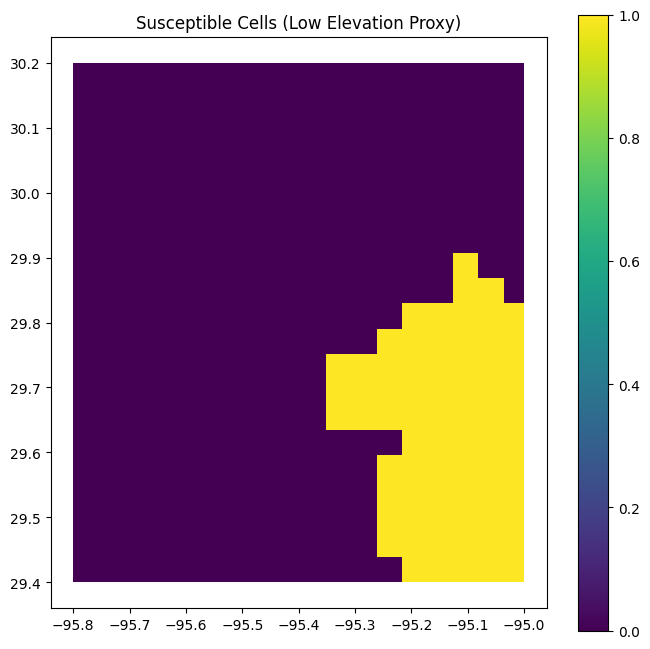

In [75]:
fig, ax = plt.subplots(figsize=(8, 8))

grid_static.plot(
    column="is_susceptible",
    ax=ax,
    legend=True
)

ax.set_title("Susceptible Cells (Low Elevation Proxy)")
fig.savefig("../outputs/figures/houston_susceptibility.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
model_df.to_parquet(PROCESSED_DIR / "grid_model_table_v1.parquet", index=False)

## Validation: Proxy Label vs Observed Flood Events

### Objective
Evaluate whether the proxy-defined flood-prone states align with real-world flood event reports.

### Approach
Instead of expecting exact spatial overlap, we test whether:
- Flood events occur more frequently in proxy-positive (high-risk) grid cells
- Compared to proxy-negative (low-risk) cells

### Key Idea
Flood reports are localized and sparse, while the proxy represents broader structural vulnerability.  
The goal is to assess **statistical enrichment**, not perfect visual alignment.

### Metric
Event density comparison:
- Event rate in high-risk cells
- Event rate in low-risk cells

If the proxy is meaningful, high-risk cells should show **higher event frequency**.

In [67]:
houston_events = pd.read_parquet(
    INTERIM_DIR / "labels" / "houston_flood_events.parquet"
)

print(houston_events.shape)

(128, 53)


In [68]:
# Convert events to GeoDataFrame
events_gdf = gpd.GeoDataFrame(
    houston_events,
    geometry=gpd.points_from_xy(houston_events["BEGIN_LON"], houston_events["BEGIN_LAT"]),
    crs=CRS_GEO
)

print("Events:", events_gdf.shape)
events_gdf.head()

Events: (128, 54)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,source_file,BEGIN_DATETIME,geometry
0,201701,18,810,201701,18,1010,112990,675235,TEXAS,48,...,29.5897,-95.4473,29.7156,-95.2048,A slow moving upper level storm system combine...,There was widespread flooding and numerous roa...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,2017-01-18,POINT (-95.4473 29.5897)
1,201701,20,1910,201701,20,2015,112974,675098,TEXAS,48,...,29.7598,-95.3668,29.6487,-95.5412,Slow moving showers and thunderstorms produced...,There were numerous road closures between the ...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,2017-01-20,POINT (-95.3668 29.7598)
2,201703,29,1330,201703,29,1530,113876,687225,TEXAS,48,...,29.4948,-95.2221,29.4903,-95.1677,A line of thunderstorms moved across southeast...,Street flooding was reported across the Friend...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,2017-03-29,POINT (-95.2221 29.4948)
3,201703,29,1333,201703,29,1515,113876,687227,TEXAS,48,...,29.5771,-95.3785,29.5215,-95.3854,A line of thunderstorms moved across southeast...,Street flooding was reported across the Pearla...,CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,2017-03-29,POINT (-95.3785 29.5771)
4,201703,29,1415,201703,29,1605,113876,687236,TEXAS,48,...,29.6627,-95.2367,29.6197,-95.2048,A line of thunderstorms moved across southeast...,"Street flooding was reported across the area, ...",CSV,StormEvents_details-ftp_v1.0_d2017_c20260323.c...,2017-03-29,POINT (-95.2367 29.6627)


In [69]:
events_proj = events_gdf.to_crs(CRS_PROJECTED)
grid_proj = grid_gdf.to_crs(CRS_PROJECTED)

In [70]:
event_to_grid = gpd.sjoin_nearest(
    events_proj[["geometry"]],
    grid_proj[["grid_id", "geometry"]],
    how="left",
    distance_col="distance_m"
)

print(event_to_grid.shape)
event_to_grid.head()

(128, 4)


,geometry,index_right,grid_id,distance_m
0,POINT (-10625144.834 3450917.882),151,151,0.0
1,POINT (-10616183.615 3472711.589),198,198,0.0
2,POINT (-10600075.684 3438774.992),254,254,0.0
3,POINT (-10617486.053 3449304.998),193,193,0.0
4,POINT (-10601700.949 3460266.339),258,258,0.0


In [71]:
print(event_to_grid["distance_m"].describe())

count    128.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: distance_m, dtype: float64


In [72]:
event_counts = (
    event_to_grid.groupby("grid_id")
    .size()
    .reset_index(name="event_count")
)

event_counts.head()

,grid_id,event_count
0,3,1
1,4,2
2,7,2
3,12,1
4,17,1


In [73]:
grid_events = grid_static.merge(
    event_counts,
    on="grid_id",
    how="left"
)

grid_events["event_count"] = grid_events["event_count"].fillna(0)

In [74]:
high_risk = grid_events[grid_events["is_susceptible"] == 1]
low_risk = grid_events[grid_events["is_susceptible"] == 0]

high_rate = high_risk["event_count"].sum() / len(high_risk)
low_rate = low_risk["event_count"].sum() / len(low_risk)

print("High-risk event rate:", high_rate)
print("Low-risk event rate:", low_rate)
print("Ratio (high / low):", high_rate / low_rate)

High-risk event rate: 0.5
Low-risk event rate: 0.3006535947712418
Ratio (high / low): 1.6630434782608696


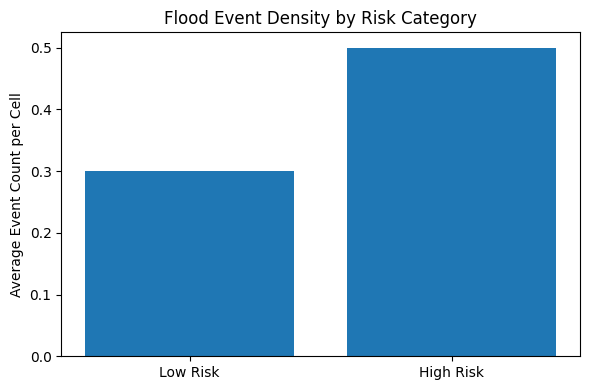

In [76]:
labels = ["Low Risk", "High Risk"]
values = [low_rate, high_rate]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Average Event Count per Cell")
plt.title("Flood Event Density by Risk Category")
plt.tight_layout()
plt.savefig("../outputs/figures/event_rate_comparison.png", dpi=300)
plt.show()